# Pandas intro — PETase thermostability dataset

Day 5 of Week 0. Practicing pandas using a synthetic dataset that mimics
the kind of mutation/thermostability data we'll encounter in Phase 1-2 of
the project.

Goal: build comfort with the 10 core pandas operations you'll use constantly:
load, inspect, select, filter, sort, summarize, group, aggregate, plot, save.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

pandas version: 2.3.3
numpy version: 2.2.6


In [4]:
df = pd.read_csv("../data/thermostability_practice.csv")
df


,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
0,S121E,121,S,E,-2.41,4.8,FoldX,high
1,L117F,117,L,F,-1.83,3.5,ThermoMPNN,high
2,W159H,159,W,H,1.24,-1.8,FoldX,medium
3,N246D,246,N,D,-0.87,1.2,FoldX,medium
4,S121P,121,S,P,-1.95,3.9,ThermoMPNN,high
5,R280A,280,R,A,2.31,-3.4,FoldX,low
6,D186H,186,D,H,-2.18,4.1,ThermoMPNN,high
7,S214H,214,S,H,-3.02,5.7,FoldX,high
8,N233K,233,N,K,-1.42,2.6,ThermoMPNN,medium
9,H218S,218,H,S,0.34,-0.6,FoldX,low


## Inspecting the data

Before doing anything, always check: how big is it, what columns do I have,
what types are they, are there missing values? Five quick operations cover this.

In [5]:
print("Shape:", df.shape)
print()
print("Columns:", list(df.columns))
print()
print("Data types:")
print(df.dtypes)

Shape: (50, 8)

Columns: ['mutation', 'position', 'wildtype_aa', 'mutant_aa', 'ddG_kcal_mol', 'Tm_change_C', 'method', 'confidence']

Data types:
mutation         object
position          int64
wildtype_aa      object
mutant_aa        object
ddG_kcal_mol    float64
Tm_change_C     float64
method           object
confidence       object
dtype: object


In [4]:
df.head()

,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
0,S121E,121,S,E,-2.41,4.8,FoldX,high
1,L117F,117,L,F,-1.83,3.5,ThermoMPNN,high
2,W159H,159,W,H,1.24,-1.8,FoldX,medium
3,N246D,246,N,D,-0.87,1.2,FoldX,medium
4,S121P,121,S,P,-1.95,3.9,ThermoMPNN,high


In [5]:
df.tail(3)

,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
47,H218N,218,H,N,-0.41,0.8,FoldX,low
48,S121H,121,S,H,-1.87,3.5,ThermoMPNN,high
49,N246T,246,N,T,-0.96,1.8,FoldX,medium


In [6]:
df.sample(5, random_state=42)

,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
13,N246M,246,N,M,-1.21,2.3,ThermoMPNN,medium
39,L155I,155,L,I,-0.61,1.1,FoldX,medium
30,T199I,199,T,I,-1.47,2.7,ThermoMPNN,medium
45,G62A,62,G,A,-0.92,1.7,FoldX,medium
17,T88C,88,T,C,-1.93,3.7,FoldX,medium


In [7]:
df.describe()

,position,ddG_kcal_mol,Tm_change_C
count,50.000000,50.000000,50.000000
mean,170.380000,-0.976800,1.918000
std,58.962766,1.269285,2.186386
min,62.000000,-3.020000,-4.200000
25%,121.000000,-1.830000,1.025000
50%,169.500000,-1.160000,2.150000
75%,221.000000,-0.565000,3.500000
max,280.000000,2.940000,5.700000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mutation      50 non-null     object 
 1   position      50 non-null     int64  
 2   wildtype_aa   50 non-null     object 
 3   mutant_aa     50 non-null     object 
 4   ddG_kcal_mol  50 non-null     float64
 5   Tm_change_C   50 non-null     float64
 6   method        50 non-null     object 
 7   confidence    50 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 3.2+ KB


## Selecting columns and rows

Now we slice and filter. Two main operations:
- `df[col]` or `df[[col1, col2]]` for picking columns
- `df[df[col] > x]` for picking rows that meet conditions

Combining these answers questions like "show me all mutations where ddG < -2."

In [12]:
df['ddG_kcal_mol']

0    -2.41
1    -1.83
2     1.24
3    -0.87
4    -1.95
5     2.31
6    -2.18
7    -3.02
8    -1.42
9     0.34
10   -2.87
11   -1.66
12    2.94
13   -1.21
14   -0.45
15   -1.78
16   -2.55
17   -1.93
18   -0.92
19   -1.45
20   -0.88
21    1.84
22   -2.23
23   -0.67
24    0.98
25   -1.34
26   -1.05
27   -0.78
28   -2.04
29    1.56
30   -1.47
31   -0.32
32   -1.18
33   -0.55
34   -0.89
35   -1.72
36   -0.43
37   -1.96
38   -1.28
39   -0.61
40   -1.83
41   -0.74
42   -0.55
43   -1.14
44   -1.61
45   -0.92
46   -2.12
47   -0.41
48   -1.87
49   -0.96
Name: ddG_kcal_mol, dtype: float64

In [13]:
df[['mutation', 'ddG_kcal_mol', 'Tm_change_C']]

,mutation,ddG_kcal_mol,Tm_change_C
0,S121E,-2.41,4.8
1,L117F,-1.83,3.5
2,W159H,1.24,-1.8
3,N246D,-0.87,1.2
4,S121P,-1.95,3.9
5,R280A,2.31,-3.4
6,D186H,-2.18,4.1
7,S214H,-3.02,5.7
8,N233K,-1.42,2.6
9,H218S,0.34,-0.6


In [14]:
df[df['ddG_kcal_mol'] < -2]

,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
0,S121E,121,S,E,-2.41,4.8,FoldX,high
6,D186H,186,D,H,-2.18,4.1,ThermoMPNN,high
7,S214H,214,S,H,-3.02,5.7,FoldX,high
10,S238F,238,S,F,-2.87,5.3,ThermoMPNN,high
16,F125W,125,F,W,-2.55,4.9,FoldX,high
22,H184Y,184,H,Y,-2.23,4.3,ThermoMPNN,high
28,S121A,121,S,A,-2.04,3.8,FoldX,high
46,F222W,222,F,W,-2.12,4.0,ThermoMPNN,high


In [15]:
df['ddG_kcal_mol'] < -2

0      True
1     False
2     False
3     False
4     False
5     False
6      True
7      True
8     False
9     False
10     True
11    False
12    False
13    False
14    False
15    False
16     True
17    False
18    False
19    False
20    False
21    False
22     True
23    False
24    False
25    False
26    False
27    False
28     True
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46     True
47    False
48    False
49    False
Name: ddG_kcal_mol, dtype: bool

In [16]:
df[(df['ddG_kcal_mol'] < -2) & (df['confidence'] == 'high')]


,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
0,S121E,121,S,E,-2.41,4.8,FoldX,high
6,D186H,186,D,H,-2.18,4.1,ThermoMPNN,high
7,S214H,214,S,H,-3.02,5.7,FoldX,high
10,S238F,238,S,F,-2.87,5.3,ThermoMPNN,high
16,F125W,125,F,W,-2.55,4.9,FoldX,high
22,H184Y,184,H,Y,-2.23,4.3,ThermoMPNN,high
28,S121A,121,S,A,-2.04,3.8,FoldX,high
46,F222W,222,F,W,-2.12,4.0,ThermoMPNN,high


In [17]:
df.sort_values('ddG_kcal_mol').head(10)

,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
7,S214H,214,S,H,-3.02,5.7,FoldX,high
10,S238F,238,S,F,-2.87,5.3,ThermoMPNN,high
16,F125W,125,F,W,-2.55,4.9,FoldX,high
0,S121E,121,S,E,-2.41,4.8,FoldX,high
22,H184Y,184,H,Y,-2.23,4.3,ThermoMPNN,high
6,D186H,186,D,H,-2.18,4.1,ThermoMPNN,high
46,F222W,222,F,W,-2.12,4.0,ThermoMPNN,high
28,S121A,121,S,A,-2.04,3.8,FoldX,high
37,F222Y,222,F,Y,-1.96,3.7,FoldX,high
4,S121P,121,S,P,-1.95,3.9,ThermoMPNN,high


In [18]:
df.sort_values('ddG_kcal_mol', ascending=False).head(10)

,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
12,W185S,185,W,S,2.94,-4.2,FoldX,low
5,R280A,280,R,A,2.31,-3.4,FoldX,low
21,R90S,90,R,S,1.84,-2.7,FoldX,low
29,P181S,181,P,S,1.56,-2.3,FoldX,low
2,W159H,159,W,H,1.24,-1.8,FoldX,medium
24,W159Y,159,W,Y,0.98,-1.4,FoldX,medium
9,H218S,218,H,S,0.34,-0.6,FoldX,low
31,G89A,89,G,A,-0.32,0.5,FoldX,low
47,H218N,218,H,N,-0.41,0.8,FoldX,low
36,H237N,237,H,N,-0.43,0.8,ThermoMPNN,low


In [19]:
df.sort_values(['confidence', 'ddG_kcal_mol']).head(15)


,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
7,S214H,214,S,H,-3.02,5.7,FoldX,high
10,S238F,238,S,F,-2.87,5.3,ThermoMPNN,high
16,F125W,125,F,W,-2.55,4.9,FoldX,high
0,S121E,121,S,E,-2.41,4.8,FoldX,high
22,H184Y,184,H,Y,-2.23,4.3,ThermoMPNN,high
6,D186H,186,D,H,-2.18,4.1,ThermoMPNN,high
46,F222W,222,F,W,-2.12,4.0,ThermoMPNN,high
28,S121A,121,S,A,-2.04,3.8,FoldX,high
37,F222Y,222,F,Y,-1.96,3.7,FoldX,high
4,S121P,121,S,P,-1.95,3.9,ThermoMPNN,high


In [20]:
stabilizing = df[(df['ddG_kcal_mol'] < -2) & (df['confidence'] == 'high')]
stabilizing_sorted = stabilizing.sort_values('ddG_kcal_mol')
stabilizing_sorted

,mutation,position,wildtype_aa,mutant_aa,ddG_kcal_mol,Tm_change_C,method,confidence
7,S214H,214,S,H,-3.02,5.7,FoldX,high
10,S238F,238,S,F,-2.87,5.3,ThermoMPNN,high
16,F125W,125,F,W,-2.55,4.9,FoldX,high
0,S121E,121,S,E,-2.41,4.8,FoldX,high
22,H184Y,184,H,Y,-2.23,4.3,ThermoMPNN,high
6,D186H,186,D,H,-2.18,4.1,ThermoMPNN,high
46,F222W,222,F,W,-2.12,4.0,ThermoMPNN,high
28,S121A,121,S,A,-2.04,3.8,FoldX,high


## Grouping and aggregating

GroupBy is the "split-apply-combine" pattern: split data into groups,
apply a function to each group, combine results.

Example questions it answers:
- "What's the average ddG per prediction method?"
- "How many high-confidence mutations are at each position?"
- "Which method predicts more stabilizing mutations on average?"


In [22]:
df.groupby('method')['ddG_kcal_mol'].mean()

method
FoldX        -0.579286
ThermoMPNN   -1.482727
Name: ddG_kcal_mol, dtype: float64

In [23]:
df.groupby('method')['ddG_kcal_mol'].agg(['mean', 'std', 'min', 'max', 'count'])

,mean,std,min,max,count
method,,,,,
FoldX,-0.579286,1.503862,-3.02,2.94,28
ThermoMPNN,-1.482727,0.610396,-2.87,-0.43,22


In [24]:
df.groupby(['method', 'confidence']).size()

method      confidence
FoldX       high           8
            low            9
            medium        11
ThermoMPNN  high          10
            low            1
            medium        11
dtype: int64

## Saving results

Always save important intermediate results to disk. Future-you and collaborators
need to access them without re-running everything.

In [25]:
top_candidates = df[(df['ddG_kcal_mol'] < -2) & (df['confidence'] == 'high')].sort_values('ddG_kcal_mol')
top_candidates.to_csv('../data/top_candidates.csv', index=False)
print(f"Saved {len(top_candidates)} candidates to data/top_candidates.csv")

Saved 8 candidates to data/top_candidates.csv


## Plotting

Pandas integrates with matplotlib. `df.plot()` and friends give you publication-
quality plots in one line. We'll do two: a histogram of ddG values, and a
scatter of ddG vs Tm change colored by method.

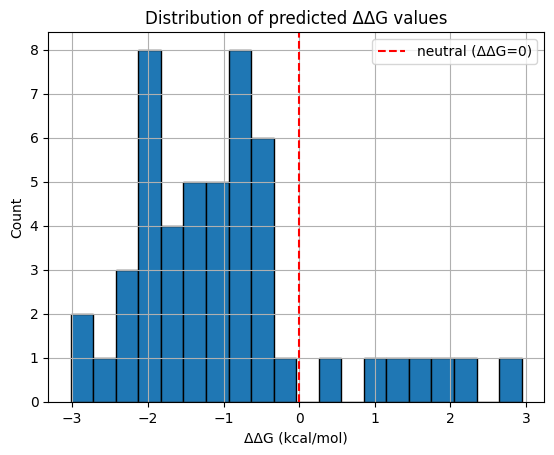

In [26]:
df['ddG_kcal_mol'].hist(bins=20, edgecolor='black')
plt.xlabel('ΔΔG (kcal/mol)')
plt.ylabel('Count')
plt.title('Distribution of predicted ΔΔG values')
plt.axvline(0, color='red', linestyle='--', label='neutral (ΔΔG=0)')
plt.legend()
plt.show()


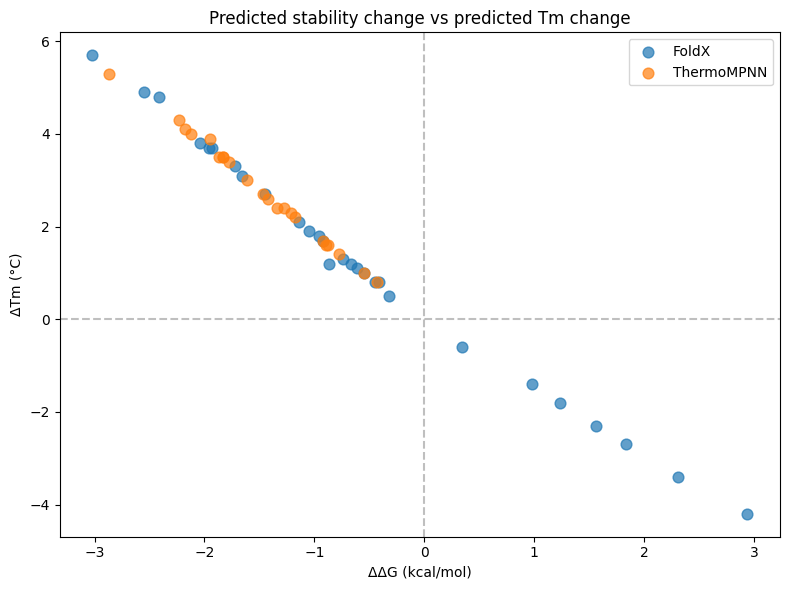

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for method in df['method'].unique():
    subset = df[df['method'] == method]
    ax.scatter(subset['ddG_kcal_mol'], subset['Tm_change_C'],
               label=method, alpha=0.7, s=60)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('ΔΔG (kcal/mol)')
ax.set_ylabel('ΔTm (°C)')
ax.set_title('Predicted stability change vs predicted Tm change')
ax.legend()
plt.tight_layout()
plt.show()